### Methods

This section describes the data and methods used to develop and evaluate machine learning models for predicting mortality in septic shock patients based on gene expression and clinical data.

#### Data Collection and Preprocessing

*   **Data Sources:** Gene expression data was obtained from `gene_exp_v2.csv` and metadata from `meta_v2.csv`.
*   **Data Merging:** The gene expression data, which was initially transposed and indexed by sample accession numbers, was merged with the metadata based on the 'Accession' column.
*   **Data Cleaning:**
    *   Columns with potentially irrelevant or redundant information were dropped (e.g., 'Unnamed: 0' and potentially 'Male', 'Female', 'Age', 'SepticShock', 'Sepsis' in one version of the merged data).
    *   Rows with missing values in the 'Age' column were removed, and samples with an age of 0 were excluded.
*   **Target Variable Encoding:** The 'Mortality' column was label encoded to convert categorical outcomes into numerical values (e.g., 'Survived' -> 1, 'Dead' -> 0).
*   **Data Filtering:** The dataset was filtered to include only patients diagnosed with Septic Shock.
*   **Feature Scaling:** The features were scaled using `MinMaxScaler` to normalize the range of values.
*   **Handling Class Imbalance:** The SMOTE (Synthetic Minority Over-sampling Technique) method was applied to the training data to address class imbalance in the target variable ('Mortality').

#### Model Development and Evaluation

*   **Data Splitting:** The preprocessed data was split into training and testing sets using an 80/20 ratio with stratification to maintain the proportion of the target variable in both sets. A fixed random state was used for reproducibility.
*   **Model Selection:** Several machine learning classifiers were evaluated, including:
    *   Logistic Regression
    *   Random Forest
    *   Bagging Classifier
    *   XGBoost
    *   LightGBM
    *   K-Nearest Neighbors
    *   Support Vector Machine (SVC)
    *   Gaussian Naive Bayes
    *   AdaBoost Classifier
    *   Linear Discriminant Analysis (LDA)
    *   Logistic Regression with Elastic Net Penalty
    *   Extra Trees Classifier
    *   Quadratic Discriminant Analysis (QDA)
    *   Gradient Boosting Classifier
    *   Voting Classifier (ensemble of selected models)
    *   Stacking Classifier (ensemble with a Logistic Regression final estimator)
*   **Hyperparameter Tuning:** For each model, hyperparameter tuning was performed using `GridSearchCV` with stratified k-fold cross-validation (5 folds) on the training data. The `roc_auc` score was used as the evaluation metric for grid search.
*   **Model Training:** Each classifier was trained on the resampled training data using the best hyperparameters found during grid search (or pre-defined parameters loaded from a file).
*   **Model Evaluation:** The trained models were evaluated on the unseen test set using the following metrics:
    *   Accuracy
    *   F1 Score
    *   Recall
    *   Precision
    *   ROC-AUC (Receiver Operating Characteristic - Area Under Curve)
    *   AUC-PR (Area Under the Precision-Recall Curve)
    *   Confusion Matrix
*   **Result Comparison:** The performance metrics for all models were collected and presented in a table for comparison. ROC curves were plotted to visualize the trade-off between true positive rate and false positive rate for different models.
*   **Feature Importance (SHAP):** SHAP (SHapley Additive exPlanations) was used to interpret the predictions of selected models and identify the most important features influencing the mortality outcome. Beeswarm plots were generated to visualize the impact of features across the dataset.

#### Software and Libraries

All analyses were performed using Python with the following libraries: pandas, numpy, sklearn, cuml, lightgbm, xgboost, imblearn, collections, matplotlib, seaborn, warnings, joblib, json, and shap.

In [ ]:
!pip install cuml-cu12 --extra-index-url=https://pypi.nvidia.com

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, balanced_accuracy_score, f1_score, precision_recall_curve, recall_score, precision_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, average_precision_score
from scipy.stats import loguniform
from sklearn.model_selection import train_test_split, GridSearchCV,  StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, StackingClassifier, AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from cuml.svm import SVC
import lightgbm as lgb
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from tqdm import tqdm
import torch
torch.cuda.is_available()
from collections import Counter
from matplotlib import pyplot as plt
import warnings
import joblib
warnings.filterwarnings("ignore")

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 41.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cuda-nvcc-cu12
    Found existing installation: nvidia-cuda-nvcc-cu12 12.5.82
    Uninstalling nvidia-cuda-nvcc-cu12-12.5.82:
      Successfully uninstalled nvidia-cuda-nvcc-cu12-12.5.82


In [ ]:
!pip install "tabpfn @ git+https://github.com/PriorLabs/TabPFN.git"
from tabpfn import TabPFNClassifier

# from functools import partial
# from torch.optim import Adam, Optimizer
# from torch.utils.data import DataLoader
# from tabpfn.finetune_utils import clone_model_for_evaluation
# from tabpfn.utils import meta_dataset_collator
import os
os.environ['HF_TOKEN']="ENTER_YOUR_HUGGINGFACE_TOKEN_HERE"

  Cloning https://github.com/PriorLabs/TabPFN.git to /tmp/pip-install-2kwmqy6v/tabpfn_5fb6a4c65caa4ccea435eea1105c2eb4
  Running command git clone --filter=blob:none --quiet https://github.com/PriorLabs/TabPFN.git /tmp/pip-install-2kwmqy6v/tabpfn_5fb6a4c65caa4ccea435eea1105c2eb4
  Resolved https://github.com/PriorLabs/TabPFN.git to commit ea9f11e0f332784f33dc41247a7d77ee89008fe2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 7.4 MB/s eta 0:00:00
  Created wheel for tabpfn: filename=tabpfn-6.4.1-py3-none-any.whl size=622885 sha256=b56a10c966ed71c9fa0d091cd4dfee53d5e14e946ffef7e18382ebe3baef6bff
  Stored in directory: /tmp/pip-ephem-wheel-cache-4g20_fb4/wheels/df/f4/05/8e4d074803d44fdeb5914b7e76831d3938b70128cb9bc93303
Successfully built tabpfn
  Attempting uninstal

##### Preprocessing

In [ ]:
# import pandas as pd
# df=pd.read_csv('gene_exp_v2.csv').T
# df.columns = df.iloc[0]
# df = df.iloc[1:]
# meta=pd.read_csv('meta_v2.csv')
# meta = meta.groupby('Accession', as_index=False).agg(lambda x: x.mean() if pd.api.types.is_numeric_dtype(x) else x.iloc[0])
# df["Accession"] = df.index.to_series().str.split("::").str[1]
# df = df.groupby('Accession', as_index=False).agg(lambda x: x.mean() if pd.api.types.is_numeric_dtype(x) else x.iloc[0])
# df= pd.merge(df, meta, on='Accession', how='inner')
# df.to_csv('merged_with_meta_v2.csv')

In [ ]:
# import pandas as pd
# df=pd.read_csv('gene_exp_v2.csv').T
# df.columns = df.iloc[0]
# df = df.iloc[1:]
# meta=pd.read_csv('meta_v2.csv')
# meta=meta.drop(columns=['Male','Female','Age','SepticShock','Sepsis'])
# meta = meta.groupby('Accession', as_index=False).agg(lambda x: x.mean() if pd.api.types.is_numeric_dtype(x) else x.iloc[0])
# df["Accession"] = df.index.to_series().str.split("::").str[1]
# df = df.groupby('Accession', as_index=False).agg(lambda x: x.mean() if pd.api.types.is_numeric_dtype(x) else x.iloc[0])
# df= pd.merge(df, meta, on='Accession', how='inner')
# df.to_csv('merged_without_meta_v2.csv')

In [ ]:
# df_1=pd.read_csv('gene_exp.csv').T.reset_index()
# df_1.columns = df_1.iloc[0]
# df_1 = df_1.iloc[1:].rename(columns={'Unnamed: 0':'Accession'})
# # df_2=pd.read_csv('Netea_balanced_combat_corrected_data.csv').T.reset_index()
# # df_2.columns = df_2.iloc[0]
# # df_2 = df_2.iloc[1:].rename(columns={'Gene':'Sample_Name'})
# # df_3=pd.read_csv('Netea_impaired_combat_corrected_data.csv').T.reset_index()
# # df_3.columns = df_3.iloc[0]
# # df_3 = df_3.iloc[1:].rename(columns={'Gene':'Sample_Name'})

# meta=pd.read_csv('meta.csv')
# dfs = [df_1,meta]
# from functools import reduce
# # # Merge DataFrames using reduce and a lambda function
# df= reduce(lambda left, right: pd.merge(left, right, on='Accession',how='inner'), dfs)
# df.to_csv('merged_data_with_meta.csv')

In [ ]:
df=pd.read_csv('merged_with_meta_v2.csv')
df.drop(columns=['Unnamed: 0'],inplace=True)

##### Empty Values


In [ ]:
# label_encoder = LabelEncoder()
# df['Mortality'] = label_encoder.fit_transform(df['Mortality'])
# print("Label Encoding rules:")
# for idx, class_ in enumerate(label_encoder.classes_):
#     print(f"{class_} -> {idx}")

In [ ]:
# Converting Columns that are Objects into Numeric Values
# df = df.apply(lambda col: pd.to_numeric(col, errors='coerce') if col.dtype == 'object' else col)

##### Negative Values

In [ ]:
# numeric_columns = df.select_dtypes(include=[int, float]).columns
# columns_with_negative_values = df[numeric_columns].columns[(df[numeric_columns] < 0).any()]


# print(columns_with_negative_values)

#### EDA

In [ ]:
# df=df.dropna(subset=['Age'])
# df=df[df['Age'] != 0]

In [ ]:
df.shape

(1088, 283)

In [ ]:
df.columns

Index(['Accession', 'ABHD4', 'ADCY4', 'ADIPOR1', 'AEBP2', 'ALG8', 'AQP9',
       'ARPC4', 'ASAH1', 'ATG3',
       ...
       'ZNF227', 'ZNF341', 'ZNF75A', 'ZZZ3', 'Male', 'Female', 'Age',
       'SepticShock', 'Sepsis', 'Mortality'],
      dtype='object', length=283)

##### Ranges

In [ ]:
# df_genes=df.drop(columns=['Accession','Male','Female','Mortality','Age','Sepsis','SepticShock'],axis=1)
# df_genes = df_genes.melt(var_name='Column', value_name='Value')
# df_genes['Value'] = pd.to_numeric(df_genes['Value'], errors='coerce')

In [ ]:
# # Convert all columns except "Accession" to numeric
# df_numeric = df.drop(columns=["Accession"]).apply(pd.to_numeric, errors="coerce")

# # Mask for rows where any value > 20
# mask = (df_numeric > 20).any(axis=1)

# # Pull out corresponding Accession numbers
# accessions_over20 = df.loc[mask, "Accession"]

# accessions_over20.to_csv("accessions_over20.csv", index=False)

In [ ]:
# df_genes['Value'].describe()

In [ ]:
# df_genes.boxplot(column='Value')

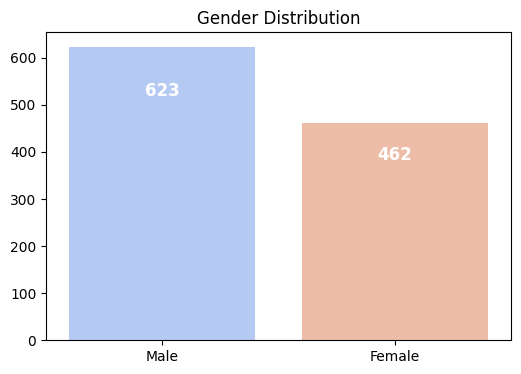

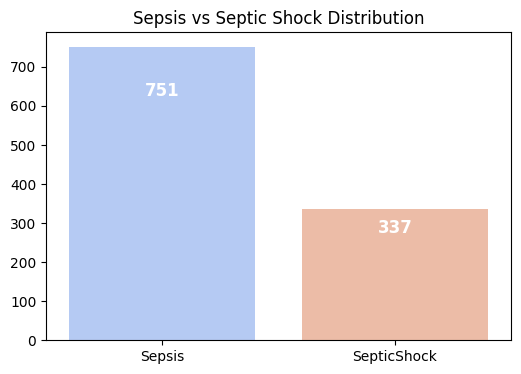

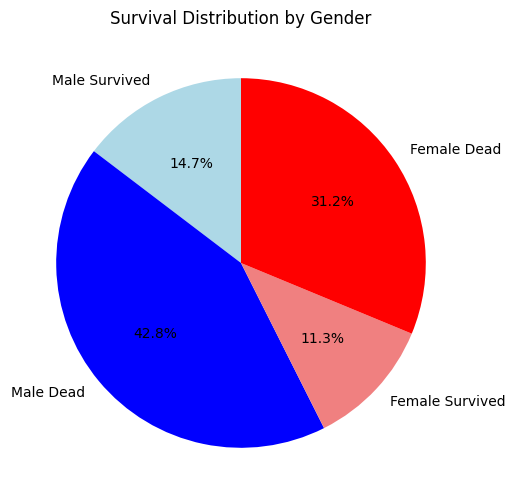

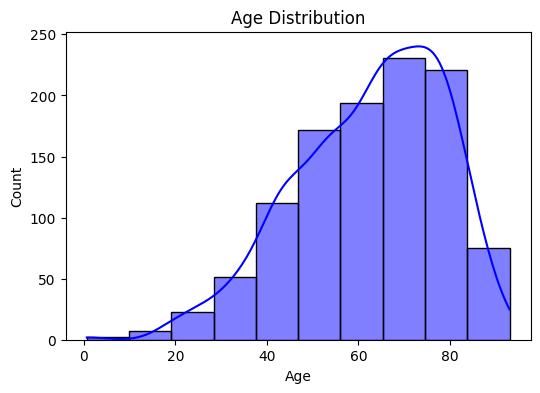

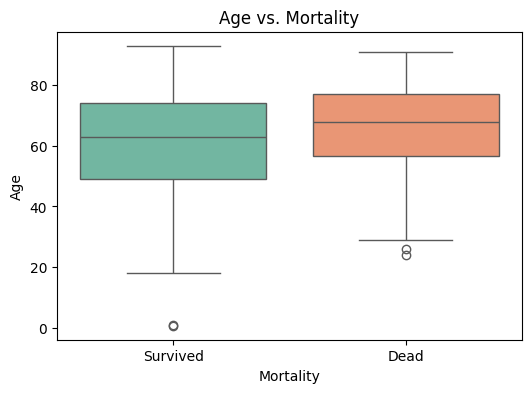

Overall 28-day mortality was 26.10%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Gender Distribution
plt.figure(figsize=(6,4))
gender_counts = {
    "Male": df["Male"].sum(),
    "Female": df["Female"].sum()
}
# Create bar plot
ax = sns.barplot(
    x=list(gender_counts.keys()),
    y=list(gender_counts.values()),
    palette="coolwarm"
)

for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() * 0.85,   # position inside the bar (85% of height)
        f"{int(p.get_height())}",
        ha='center', va='center',
        color='white', fontsize=12, fontweight='bold'
    )


plt.title("Gender Distribution")
plt.show()

# Sepsis vs Septic Shock Distribution
plt.figure(figsize=(6,4))
septic_counts = {
    "Sepsis": df["Sepsis"].sum(),
    "SepticShock": df["SepticShock"].sum()
}


ax = sns.barplot(
    x=list(septic_counts.keys()),
    y=list(septic_counts.values()),
    palette="coolwarm"
)

for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() * 0.85,   # position inside the bar (85% of height)
        f"{int(p.get_height())}",
        ha='center', va='center',
        color='white', fontsize=12, fontweight='bold'
    )
plt.title("Sepsis vs Septic Shock Distribution")
plt.show()

# Survival Rate by Gender and Mortality (Pie Chart)
survival_counts = df.groupby(["Male", "Female", "Mortality"]).size()

labels = ["Male Survived", "Male Dead", "Female Survived", "Female Dead"]
values = [
    survival_counts.get((1, 0, 1), 0),  # Male Survived
    survival_counts.get((1, 0, 0), 0),  # Male Dead
    survival_counts.get((0, 1, 1), 0),  # Female Survived
    survival_counts.get((0, 1, 0), 0)   # Female Dead
]

colors = ["lightblue", "blue", "lightcoral", "red"]
plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct="%1.1f%%", colors=colors, startangle=90)
plt.title("Survival Distribution by Gender")
plt.show()


# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=10, kde=True, color='blue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()
# Age vs. Mortality
plt.figure(figsize=(6,4))
sns.boxplot(x='Mortality', y='Age', data=df, palette='Set2')
plt.xticks(ticks=[0, 1], labels=['Survived', 'Dead'])
plt.title('Age vs. Mortality')
plt.show()

#Mortality Percentage on the dataset
mortality_rate = df["Mortality"].mean() * 100
print(f"Overall 28-day mortality was {mortality_rate:.2f}%")



#### Extraction

In [ ]:
# X = df.drop(['Mortality'], axis=1)
# y = df.Mortality
# X = X.to_numpy()
# y = y.to_numpy()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


# Don't convert to NumPy
# df=df[['Accession', 'SEMA6B', 'ATP6V0C', 'Age', 'SLTM', 'RNMT', 'UBTD1', 'VRK2', 'RASGRP4', 'FURIN', 'WDR43','Mortality','SERBP1', 'AZU1', 'MAP3K3', 'ESCO1', 'MALT1', 'MAP1LC3A', 'Female', 'INPP5D', 'YTHDC1', 'DGCR2']]
# df = df[df['Sepsis'] != 0] #means Sepsis
df = df[df['SepticShock'] != 0] #means Septic Shock
X = df.drop(['Mortality','Accession'], axis=1)
y = df['Mortality']

# Split first
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=21, stratify=y)

# # # Scale 'Age' using column name
scaler = MinMaxScaler(feature_range=(0, 1))
# X_train['Age'] = scaler.fit_transform(X_train[['Age']])
# X_test['Age'] = scaler.transform(X_test[['Age']])


# from sklearn.preprocessing import RobustScaler
# scaler = RobustScaler()
# scaler = MinMaxScaler()
X_columns=X_train.columns
X_train = scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

# Count occurrences of unique values in the NumPy array 'y'
unique, counts = np.unique(y_train, return_counts=True)
# Get the count of the most frequent value
target_count = max(counts)
smote = SMOTE(sampling_strategy={0: target_count, 1: target_count}, random_state=21)
X_resampled_smote, y_resampled_smote = smote.fit_resample(X_train, y_train)
print("Original dataset shape:", Counter(y_train))
print("SMOTE resampled dataset shape:", Counter(y_resampled_smote))
X_train,y_train= X_resampled_smote, y_resampled_smote

cv = StratifiedKFold(n_splits=5)

training=0

Original dataset shape: Counter({0.0: 187, 1.0: 82})
SMOTE resampled dataset shape: Counter({1.0: 187, 0.0: 187})


In [ ]:
import json
if training==1:
    param={}
else:
  with open('/content/v2_with_meta_with_scale_bt_01_with_smote.json', 'rb') as file:
#   with open('/content/v2_with_meta_with_scale_with_smote_sepsis.json', 'rb') as file:
#   with open('/content/v2_with_meta_with_scale_with_smote_septic_shock.json', 'rb') as file:

      param = json.load(file)

In [ ]:
result=pd.DataFrame(columns=["Model","Accuracy","F1","Recall","Precision","ROC-AUC","AUC-PR", "Confusion Matrix"])

def metric(model, name, X, y):
    y_pred = model.predict(X)

    accuracy = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    recall = recall_score(y, y_pred)
    precision = precision_score(y, y_pred)
    matrix = confusion_matrix(y, y_pred)

    if hasattr(model, 'predict_proba'):
        y_probs = model.predict_proba(X)[:, 1]
    elif hasattr(model, 'decision_function'):
        decision_scores = model.decision_function(X)
        y_probs = (decision_scores - decision_scores.min()) / (
            decision_scores.max() - decision_scores.min()
        )
    else:
        raise AttributeError(f"{name} does not have predict_proba or decision_function")

    roc_auc = roc_auc_score(y, y_probs)
    auc_precision_recall = average_precision_score(y, y_probs)

    cmd = ConfusionMatrixDisplay(matrix, display_labels=['survive', 'death'])
    cmd.plot(cmap='Wistia')

    result.loc[len(result)] = [
        name, accuracy, f1, recall, precision, roc_auc,
        auc_precision_recall, matrix.tolist()
    ]

    return result


In [ ]:
# param={}


#### Logistic Regression

##### Grid Searching

In [ ]:
## DO NOT EXECUTE THIS CELL ##
from scipy.stats import loguniform
grid = {
    'C': np.logspace(-3, 3, 3),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}
if training==1:
  gridsearch=GridSearchCV(estimator=LogisticRegression(max_iter=100), param_grid=grid, cv=cv, scoring = "roc_auc")
  gridsearch.fit(X_train, y_train)
  params = gridsearch.best_params_

##### Model Training

{'C': 1000.0, 'penalty': 'l1', 'solver': 'saga'}


,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"


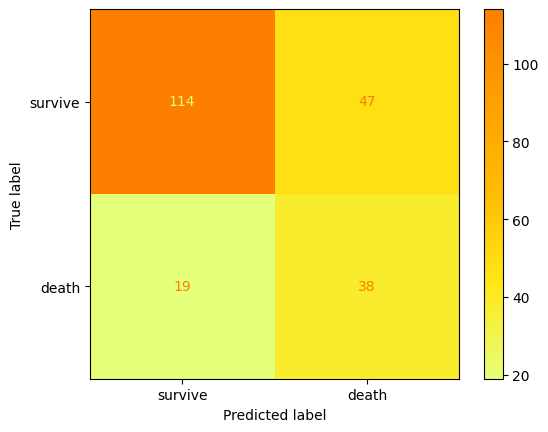

In [ ]:
if training==1:
  param['LR']=params
else:
  params=param['LR']
print(params)
logreg = LogisticRegression(**params)
logreg.fit(X_train, y_train)
# metric(logreg,'LR')


metric(logreg, "LR", X_test, y_test)

####    Random Forest


##### Grid Searching

In [ ]:
# # ## DO NOT EXECUTE THIS CELL ##

grid = {
    'bootstrap': [True],
    'max_depth': [ 90,100,110,120],
    'max_features': [7,8,9,10],
    'min_samples_leaf': [3,4,5],
    'min_samples_split': [8,10],
    'n_estimators': [40,45,50]
}
if training==1:
  gridsearch=GridSearchCV(estimator=RandomForestClassifier(), param_grid=grid, cv=cv, scoring = "roc_auc",n_jobs = -1)
  gridsearch.fit(X_train, y_train)
  params = gridsearch.best_params_

##### Model Training

{'bootstrap': True, 'max_depth': 90, 'max_features': 9, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 45}


,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"


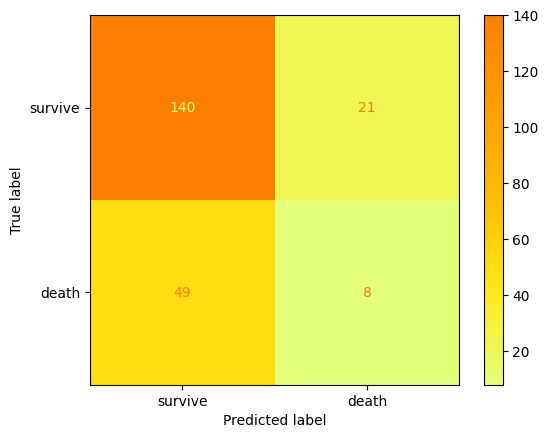

In [ ]:
if training==1:
  param['RF']=params
else:
  params=param['RF']
print(params)
RF = RandomForestClassifier(**params)
RF.fit(X_train, y_train)
metric(RF,'RF', X_test, y_test)

#### Bagging

##### Grid Search

In [ ]:
# ## DO NOT EXECUTE THIS CELL ##

grid={'n_estimators': [500, 750, 1000]}
if training==1:
  grid_search = GridSearchCV(estimator=BaggingClassifier(estimator=DecisionTreeClassifier()), param_grid=grid, n_jobs=-1, cv=cv, scoring = "roc_auc")
  grid_search.fit(X_train, y_train)
  params = grid_search.best_params_

##### Model Training

{'n_estimators': 750}


,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"
2,Bagging,0.711009,0.240964,0.175439,0.384615,0.674403,0.440643,"[[145, 16], [47, 10]]"


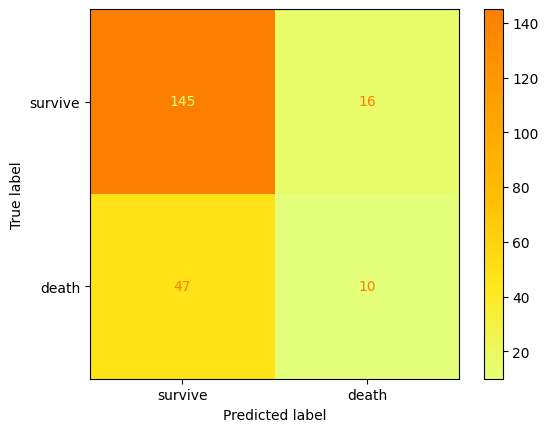

In [ ]:
if training==1:
  param['Bagging']=params
else:
  params=param['Bagging']
print(params)
bagging = BaggingClassifier(estimator=DecisionTreeClassifier(),**params)
bagging.fit(X_train, y_train)
metric(bagging,'Bagging', X_test, y_test)

#### XGB

##### Grid Searching

In [ ]:
## DO NOT EXECUTE THIS CELL ##

estimator = XGBClassifier(
    objective = 'binary:logistic',
    enable_categorical = True,
    nthread = 8,
    seed = 42,
    tree_method='gpu_hist',
    predictor='gpu_predictor',
)
grid = {
    'max_depth': range (5, 10, 1),
    'n_estimators': range(170,230,10),
    'learning_rate': [0.1,0.05]
}
if training==1:
  gridsearch = GridSearchCV(estimator=estimator, param_grid=grid,scoring = "roc_auc", n_jobs = -1,  cv=cv, verbose=True)
  gridsearch.fit(X_train, y_train)
  params = gridsearch.best_params_

##### Model Training

{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 210}


,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"
2,Bagging,0.711009,0.240964,0.175439,0.384615,0.674403,0.440643,"[[145, 16], [47, 10]]"
3,XGB,0.720183,0.383838,0.333333,0.452381,0.711997,0.422090,"[[138, 23], [38, 19]]"


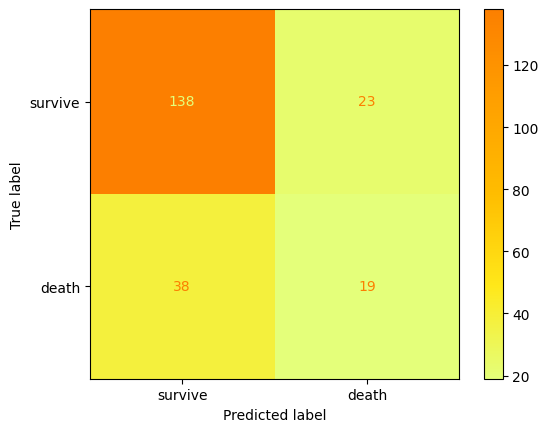

In [ ]:
if training==1:
  param['XGB']=params
else:
  params=param['XGB']
print(params)
XGB = XGBClassifier(**params)
XGB.fit(X_train, y_train)
metric(XGB,'XGB', X_test, y_test)

#### LightGBM

##### Grid Searching

In [ ]:
# # DO NOT EXECUTE THIS CELL ##

grid = {
    'n_estimators': [50, 60, 70, 80,90,100],
    'learning_rate': [0.1,0.01],
    'max_depth': [4,5,6,7,8],
    'num_leaves': [8,10,12],
    'subsample': [0.2],
    'colsample_bytree': [0.7,0.8,0.9]
}
if training==1:
  lgb_classifier = lgb.LGBMClassifier(force_col_wise=True, device='gpu', boosting_type='gbdt')
  gridsearch = GridSearchCV(estimator=lgb_classifier, param_grid=grid, cv=cv, scoring = "roc_auc", n_jobs=-1)
  gridsearch.fit(X_train, y_train)
  params = gridsearch.best_params_

##### Model Training

{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 100, 'num_leaves': 12, 'subsample': 0.2}
[LightGBM] [Info] Number of positive: 643, number of negative: 643
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003916 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 70667
[LightGBM] [Info] Number of data points in the train set: 1286, number of used features: 281
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"
2,Bagging,0.711009,0.240964,0.175439,0.384615,0.674403,0.440643,"[[145, 16], [47, 10]]"
3,XGB,0.720183,0.383838,0.333333,0.452381,0.711997,0.422090,"[[138, 23], [38, 19]]"
4,LGB,0.729358,0.415842,0.368421,0.477273,0.682794,0.398681,"[[138, 23], [36, 21]]"


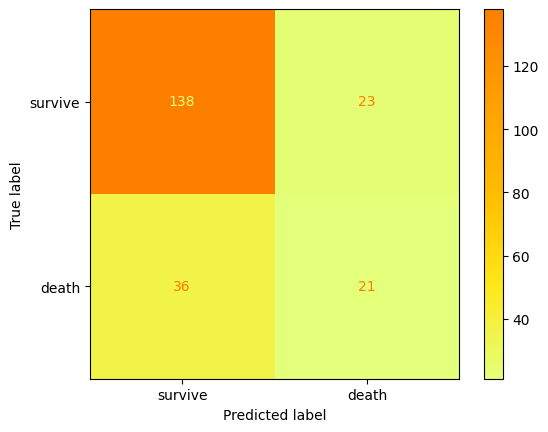

In [ ]:
if training==1:
  param['LGB']=params
else:
  params=param['LGB']
print(params)
lgb_classifier = lgb.LGBMClassifier(**params)
lgb_classifier.fit(X_train, y_train)
metric(lgb_classifier,'LGB', X_test, y_test)

#### KNN

##### Grid Search

In [ ]:
# # # ## DO NOT EXECUTE THIS CELL ##

grid = {
    'n_neighbors' : range(3, 15, 1),
    'weights': ['uniform', 'distance'],
    'metric' : ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
    }
if training==1:
  gridsearch = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=grid, cv=cv, scoring = "roc_auc", n_jobs=-1)
  gridsearch.fit(X_train, y_train)
  params = gridsearch.best_params_

##### Model Training

{'algorithm': 'auto', 'metric': 'euclidean', 'n_neighbors': 6, 'p': 1, 'weights': 'distance'}


,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"
2,Bagging,0.711009,0.240964,0.175439,0.384615,0.674403,0.440643,"[[145, 16], [47, 10]]"
3,XGB,0.720183,0.383838,0.333333,0.452381,0.711997,0.422090,"[[138, 23], [38, 19]]"
4,LGB,0.729358,0.415842,0.368421,0.477273,0.682794,0.398681,"[[138, 23], [36, 21]]"
5,KNN,0.504587,0.460000,0.807018,0.321678,0.652228,0.351487,"[[64, 97], [11, 46]]"


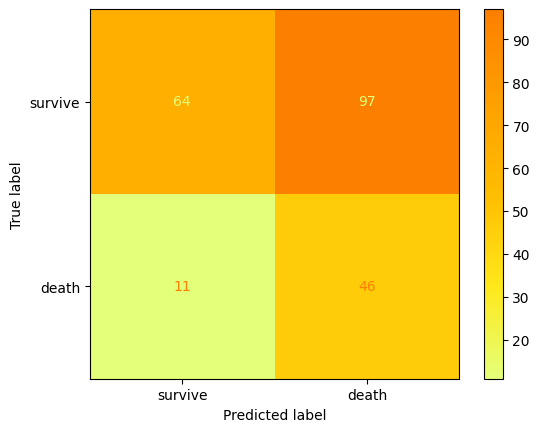

In [ ]:
if training==1:
  param['KNN']=params
else:
  params=param['KNN']
print(params)
KNN = KNeighborsClassifier(**params)
KNN.fit(X_train, y_train)
metric(KNN,'KNN', X_test, y_test)

#### SVC

##### Grid Search

In [ ]:
# # # ## DO NOT EXECUTE THIS CELL ##

grid = {
    'kernel': ['linear','poly', 'rbf', 'sigmoid'],
    'C': np.logspace(-5,3,4)
    }
if training==1:
  gridsearch = GridSearchCV(estimator=SVC(gamma='scale',probability=True), param_grid=grid, cv=cv, scoring = "roc_auc", n_jobs=-1)
  gridsearch.fit(X_train, y_train)
  params = gridsearch.best_params_

##### Model Training

{'C': 1000.0, 'kernel': 'rbf'}


,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"
2,Bagging,0.711009,0.240964,0.175439,0.384615,0.674403,0.440643,"[[145, 16], [47, 10]]"
3,XGB,0.720183,0.383838,0.333333,0.452381,0.711997,0.422090,"[[138, 23], [38, 19]]"
4,LGB,0.729358,0.415842,0.368421,0.477273,0.682794,0.398681,"[[138, 23], [36, 21]]"
5,KNN,0.504587,0.460000,0.807018,0.321678,0.652228,0.351487,"[[64, 97], [11, 46]]"
6,SVC,0.756881,0.311688,0.210526,0.600000,0.769968,0.527107,"[[153, 8], [45, 12]]"


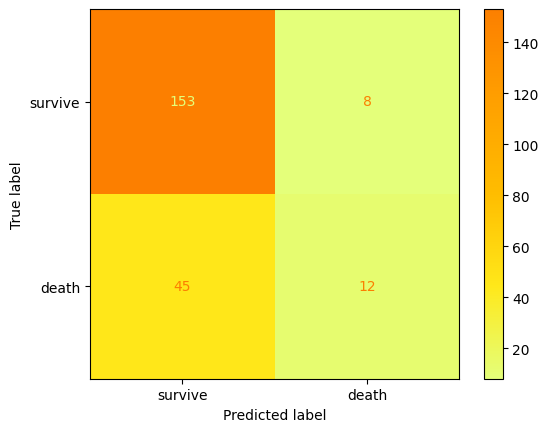

In [ ]:
if training==1:
  param['SVC']=params
else:
  params=param['SVC']
print(params)
SVCClassifier = SVC(**params,probability=True)
SVCClassifier.fit(X_train, y_train)
metric(SVCClassifier,'SVC', X_test, y_test)

#### Gaussian NB

##### Grid Search

In [ ]:
# # ## DO NOT EXECUTE THIS CELL ##

grid= {'var_smoothing': np.logspace(-5,5, num=50)}
if training==1:
  grid_search = GridSearchCV(estimator=GaussianNB(),param_grid=grid,cv=cv,verbose=1,scoring = "roc_auc",n_jobs=-1)
  grid_search.fit(X_train, y_train)
  params = grid_search.best_params_

##### Model Training

{'var_smoothing': 0.00042919342601287783}


,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"
2,Bagging,0.711009,0.240964,0.175439,0.384615,0.674403,0.440643,"[[145, 16], [47, 10]]"
3,XGB,0.720183,0.383838,0.333333,0.452381,0.711997,0.422090,"[[138, 23], [38, 19]]"
4,LGB,0.729358,0.415842,0.368421,0.477273,0.682794,0.398681,"[[138, 23], [36, 21]]"
5,KNN,0.504587,0.460000,0.807018,0.321678,0.652228,0.351487,"[[64, 97], [11, 46]]"
6,SVC,0.756881,0.311688,0.210526,0.600000,0.769968,0.527107,"[[153, 8], [45, 12]]"
7,GNB,0.545872,0.377358,0.526316,0.294118,0.553667,0.316194,"[[89, 72], [27, 30]]"


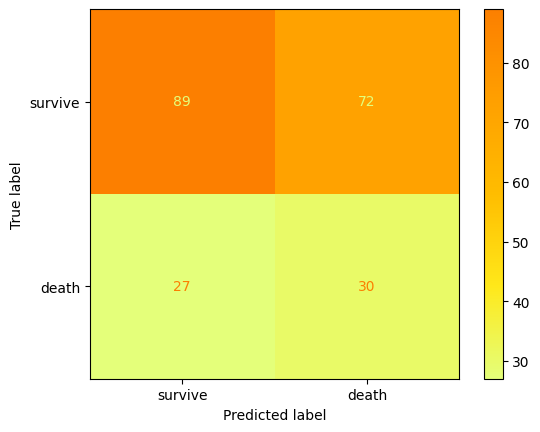

In [ ]:
if training==1:
  param['GNB']=params
else:
  params=param['GNB']
print(params)
GNB = GaussianNB(**params)
GNB.fit(X_train, y_train)
metric(GNB,'GNB', X_test, y_test)

#### AdaBoost Classifier

##### Grid Search

In [ ]:
grid = {
    'n_estimators': [200,300,400],
    'learning_rate': [0.5,1]
}

if training==1:
  gridsearch = GridSearchCV(AdaBoostClassifier(random_state=42), grid, cv=cv, scoring='roc_auc', n_jobs=-1)
  gridsearch.fit(X_train, y_train)
  params = gridsearch.best_params_

##### Model Training

{'learning_rate': 1.0, 'n_estimators': 400}


,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"
2,Bagging,0.711009,0.240964,0.175439,0.384615,0.674403,0.440643,"[[145, 16], [47, 10]]"
3,XGB,0.720183,0.383838,0.333333,0.452381,0.711997,0.422090,"[[138, 23], [38, 19]]"
4,LGB,0.729358,0.415842,0.368421,0.477273,0.682794,0.398681,"[[138, 23], [36, 21]]"
5,KNN,0.504587,0.460000,0.807018,0.321678,0.652228,0.351487,"[[64, 97], [11, 46]]"
6,SVC,0.756881,0.311688,0.210526,0.600000,0.769968,0.527107,"[[153, 8], [45, 12]]"
7,GNB,0.545872,0.377358,0.526316,0.294118,0.553667,0.316194,"[[89, 72], [27, 30]]"
8,AdaBoost,0.678899,0.406780,0.421053,0.393443,0.612292,0.381683,"[[124, 37], [33, 24]]"


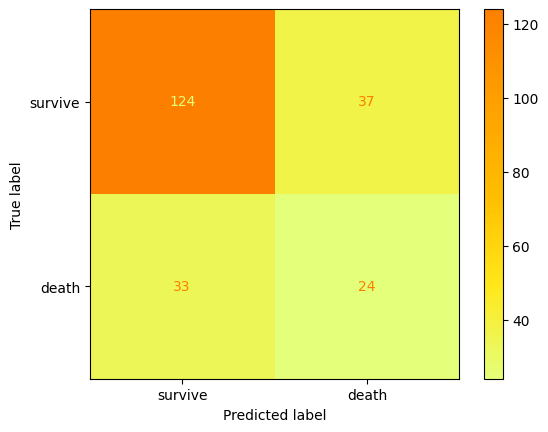

In [ ]:
if training==1:
  param['Adaboost']=params
else:
  params=param['Adaboost']
print(params)
ada_boost = AdaBoostClassifier(**params, random_state=42)
ada_boost.fit(X_train, y_train)
metric(ada_boost, 'AdaBoost', X_test, y_test)

#### LDA

##### Grid Search

In [ ]:
grid = {
    'solver': ['svd', 'lsqr', 'eigen']
}
if training==1:
  gridsearch = GridSearchCV(LinearDiscriminantAnalysis(), grid, cv=cv, scoring='roc_auc', n_jobs=-1)
  gridsearch.fit(X_train, y_train)
  params = gridsearch.best_params_

##### Model Training

{'solver': 'lsqr'}


,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"
2,Bagging,0.711009,0.240964,0.175439,0.384615,0.674403,0.440643,"[[145, 16], [47, 10]]"
3,XGB,0.720183,0.383838,0.333333,0.452381,0.711997,0.422090,"[[138, 23], [38, 19]]"
4,LGB,0.729358,0.415842,0.368421,0.477273,0.682794,0.398681,"[[138, 23], [36, 21]]"
5,KNN,0.504587,0.460000,0.807018,0.321678,0.652228,0.351487,"[[64, 97], [11, 46]]"
6,SVC,0.756881,0.311688,0.210526,0.600000,0.769968,0.527107,"[[153, 8], [45, 12]]"
7,GNB,0.545872,0.377358,0.526316,0.294118,0.553667,0.316194,"[[89, 72], [27, 30]]"
8,AdaBoost,0.678899,0.406780,0.421053,0.393443,0.612292,0.381683,"[[124, 37], [33, 24]]"
9,LDA,0.665138,0.482270,0.596491,0.404762,0.690640,0.454104,"[[111, 50], [23, 34]]"


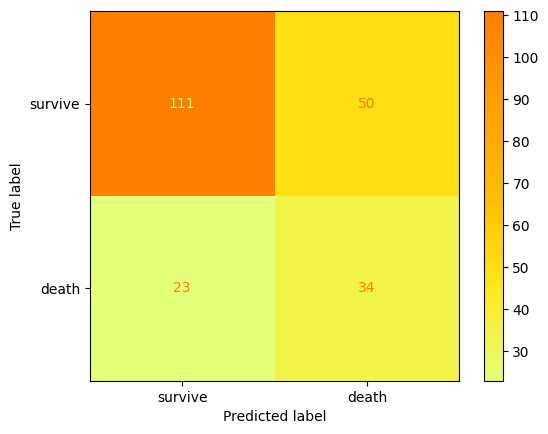

In [ ]:
if training==1:
  param['LDA']=params
else:
  params=param['LDA']
print(params)
lda_classifier = LinearDiscriminantAnalysis(**params)
lda_classifier.fit(X_train, y_train)
metric(lda_classifier, 'LDA', X_test, y_test)

#### LR (ElasticNet)

##### Grid Search

In [ ]:
grid = {
    'l1_ratio': [0.1, 0.5, 0.9],
    'C': [0.01, 0.1, 1, 10]
}
if training==1:
  elastic_lr = LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000)
  gridsearch = GridSearchCV(elastic_lr, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
  gridsearch.fit(X_train, y_train)
  params = gridsearch.best_params_

##### Model Training

{'C': 1, 'l1_ratio': 0.1}


,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"
2,Bagging,0.711009,0.240964,0.175439,0.384615,0.674403,0.440643,"[[145, 16], [47, 10]]"
3,XGB,0.720183,0.383838,0.333333,0.452381,0.711997,0.422090,"[[138, 23], [38, 19]]"
4,LGB,0.729358,0.415842,0.368421,0.477273,0.682794,0.398681,"[[138, 23], [36, 21]]"
5,KNN,0.504587,0.460000,0.807018,0.321678,0.652228,0.351487,"[[64, 97], [11, 46]]"
6,SVC,0.756881,0.311688,0.210526,0.600000,0.769968,0.527107,"[[153, 8], [45, 12]]"
7,GNB,0.545872,0.377358,0.526316,0.294118,0.553667,0.316194,"[[89, 72], [27, 30]]"
8,AdaBoost,0.678899,0.406780,0.421053,0.393443,0.612292,0.381683,"[[124, 37], [33, 24]]"
9,LDA,0.665138,0.482270,0.596491,0.404762,0.690640,0.454104,"[[111, 50], [23, 34]]"


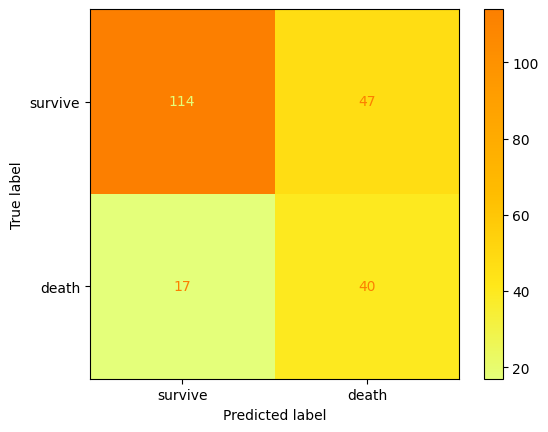

In [ ]:
if training==1:
  param['ElasticNet_LR']=params
else:
  params=param['ElasticNet_LR']
print(params)
lr_elastic = LogisticRegression(penalty='elasticnet', solver='saga', max_iter=5000, **params)
lr_elastic.fit(X_train, y_train)
metric(lr_elastic, 'ElasticNet_LR', X_test, y_test)

#### ExtraTreesClassifier

##### Grid Search

In [ ]:
grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
if training==1:
  extra_trees = ExtraTreesClassifier(random_state=42)
  gridsearch = GridSearchCV(extra_trees, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
  gridsearch.fit(X_train, y_train)
  params = gridsearch.best_params_

##### Model Training

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 500}


,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"
2,Bagging,0.711009,0.240964,0.175439,0.384615,0.674403,0.440643,"[[145, 16], [47, 10]]"
3,XGB,0.720183,0.383838,0.333333,0.452381,0.711997,0.422090,"[[138, 23], [38, 19]]"
4,LGB,0.729358,0.415842,0.368421,0.477273,0.682794,0.398681,"[[138, 23], [36, 21]]"
5,KNN,0.504587,0.460000,0.807018,0.321678,0.652228,0.351487,"[[64, 97], [11, 46]]"
6,SVC,0.756881,0.311688,0.210526,0.600000,0.769968,0.527107,"[[153, 8], [45, 12]]"
7,GNB,0.545872,0.377358,0.526316,0.294118,0.553667,0.316194,"[[89, 72], [27, 30]]"
8,AdaBoost,0.678899,0.406780,0.421053,0.393443,0.612292,0.381683,"[[124, 37], [33, 24]]"
9,LDA,0.665138,0.482270,0.596491,0.404762,0.690640,0.454104,"[[111, 50], [23, 34]]"


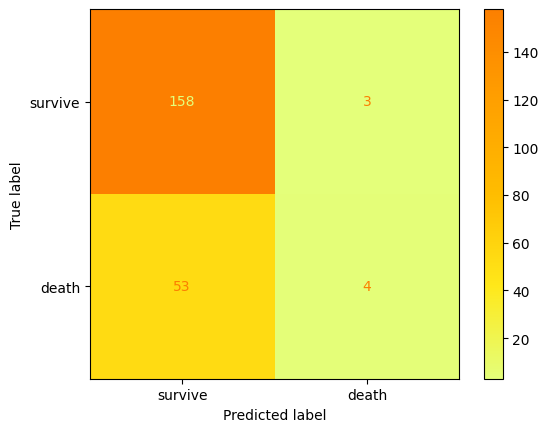

In [ ]:
if training==1:
  param['ExtraTrees']=params
else:
  params=param['ExtraTrees']
print(params)
extra_trees = ExtraTreesClassifier(**params, random_state=42)
extra_trees.fit(X_train, y_train)
metric(extra_trees, 'ExtraTrees', X_test, y_test)

#### QuadraticDiscriminantAnalysis

##### Grid Search

In [ ]:
grid = {
    'reg_param': [0.01, 0.05, 0.1, 0.5, 0.6, 0.7, 1.0]
}

if training==1:
  gridsearch = GridSearchCV(QuadraticDiscriminantAnalysis(), grid, cv=cv, scoring='roc_auc', n_jobs=-1)
  gridsearch.fit(X_train, y_train)
  params = gridsearch.best_params_

##### Model Training

{'reg_param': 0.0}


,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"
2,Bagging,0.711009,0.240964,0.175439,0.384615,0.674403,0.440643,"[[145, 16], [47, 10]]"
3,XGB,0.720183,0.383838,0.333333,0.452381,0.711997,0.422090,"[[138, 23], [38, 19]]"
4,LGB,0.729358,0.415842,0.368421,0.477273,0.682794,0.398681,"[[138, 23], [36, 21]]"
5,KNN,0.504587,0.460000,0.807018,0.321678,0.652228,0.351487,"[[64, 97], [11, 46]]"
6,SVC,0.756881,0.311688,0.210526,0.600000,0.769968,0.527107,"[[153, 8], [45, 12]]"
7,GNB,0.545872,0.377358,0.526316,0.294118,0.553667,0.316194,"[[89, 72], [27, 30]]"
8,AdaBoost,0.678899,0.406780,0.421053,0.393443,0.612292,0.381683,"[[124, 37], [33, 24]]"
9,LDA,0.665138,0.482270,0.596491,0.404762,0.690640,0.454104,"[[111, 50], [23, 34]]"


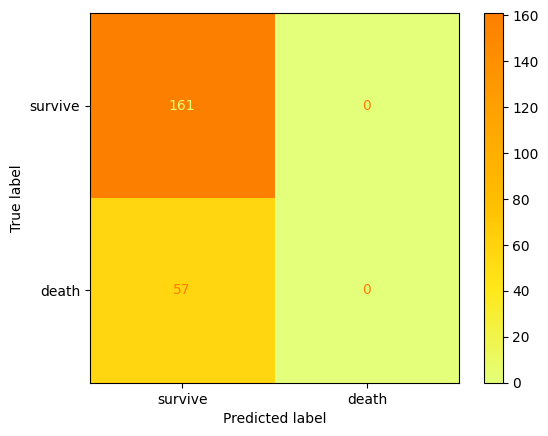

In [ ]:
if training==1:
  param['QDA']=params
else:
  params=param['QDA']
print(params)
qda_classifier = QuadraticDiscriminantAnalysis(**params)
qda_classifier.fit(X_train, y_train)
metric(qda_classifier, 'QDA', X_test, y_test)

In [ ]:
result

,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"
2,Bagging,0.711009,0.240964,0.175439,0.384615,0.674403,0.440643,"[[145, 16], [47, 10]]"
3,XGB,0.720183,0.383838,0.333333,0.452381,0.711997,0.422090,"[[138, 23], [38, 19]]"
4,LGB,0.729358,0.415842,0.368421,0.477273,0.682794,0.398681,"[[138, 23], [36, 21]]"
5,KNN,0.504587,0.460000,0.807018,0.321678,0.652228,0.351487,"[[64, 97], [11, 46]]"
6,SVC,0.756881,0.311688,0.210526,0.600000,0.769968,0.527107,"[[153, 8], [45, 12]]"
7,GNB,0.545872,0.377358,0.526316,0.294118,0.553667,0.316194,"[[89, 72], [27, 30]]"
8,AdaBoost,0.678899,0.406780,0.421053,0.393443,0.612292,0.381683,"[[124, 37], [33, 24]]"
9,LDA,0.665138,0.482270,0.596491,0.404762,0.690640,0.454104,"[[111, 50], [23, 34]]"


#### GradientBoostingClassifier

##### Grid Search

In [ ]:
grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
if training==1:
  gb = GradientBoostingClassifier(random_state=42)
  gridsearch = GridSearchCV(gb, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
  gridsearch.fit(X_train, y_train)
  params = gridsearch.best_params_

##### Model Training

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"
2,Bagging,0.711009,0.240964,0.175439,0.384615,0.674403,0.440643,"[[145, 16], [47, 10]]"
3,XGB,0.720183,0.383838,0.333333,0.452381,0.711997,0.422090,"[[138, 23], [38, 19]]"
4,LGB,0.729358,0.415842,0.368421,0.477273,0.682794,0.398681,"[[138, 23], [36, 21]]"
5,KNN,0.504587,0.460000,0.807018,0.321678,0.652228,0.351487,"[[64, 97], [11, 46]]"
6,SVC,0.756881,0.311688,0.210526,0.600000,0.769968,0.527107,"[[153, 8], [45, 12]]"
7,GNB,0.545872,0.377358,0.526316,0.294118,0.553667,0.316194,"[[89, 72], [27, 30]]"
8,AdaBoost,0.678899,0.406780,0.421053,0.393443,0.612292,0.381683,"[[124, 37], [33, 24]]"
9,LDA,0.665138,0.482270,0.596491,0.404762,0.690640,0.454104,"[[111, 50], [23, 34]]"


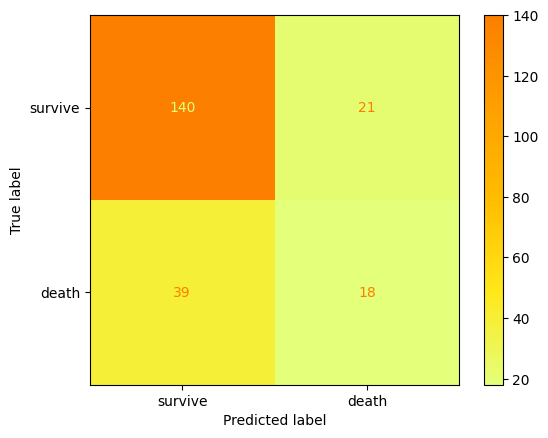

In [ ]:
if training==1:
  param['GradientBoosting']=params
else:
  params=param['GradientBoosting']
print(params)
gb_classifier = GradientBoostingClassifier(**params, random_state=42)
gb_classifier.fit(X_train, y_train)
metric(gb_classifier, 'GradientBoosting', X_test, y_test)

#### VotingClassifier

##### Model Training

,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"
2,Bagging,0.711009,0.240964,0.175439,0.384615,0.674403,0.440643,"[[145, 16], [47, 10]]"
3,XGB,0.720183,0.383838,0.333333,0.452381,0.711997,0.422090,"[[138, 23], [38, 19]]"
4,LGB,0.729358,0.415842,0.368421,0.477273,0.682794,0.398681,"[[138, 23], [36, 21]]"
5,KNN,0.504587,0.460000,0.807018,0.321678,0.652228,0.351487,"[[64, 97], [11, 46]]"
6,SVC,0.756881,0.311688,0.210526,0.600000,0.769968,0.527107,"[[153, 8], [45, 12]]"
7,GNB,0.545872,0.377358,0.526316,0.294118,0.553667,0.316194,"[[89, 72], [27, 30]]"
8,AdaBoost,0.678899,0.406780,0.421053,0.393443,0.612292,0.381683,"[[124, 37], [33, 24]]"
9,LDA,0.665138,0.482270,0.596491,0.404762,0.690640,0.454104,"[[111, 50], [23, 34]]"


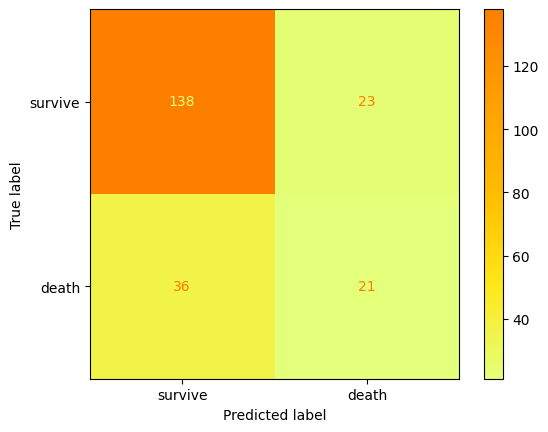

In [ ]:
voting_clf = VotingClassifier(
    estimators=[
        ('LogReg', logreg),
        ('RF', RF),
        ('XGB', XGB),
        ('LGB', lgb_classifier),
        ('KNN',KNN),
        ('SVC', SVCClassifier),
        ('GNB', GNB),
        ('AdaBoost', ada_boost),
        ('LDA', lda_classifier),
        ('ElasticNet_LR', lr_elastic),
        ('ExtraTrees', extra_trees),
        ('QDA', qda_classifier),
        ('GB', gb_classifier)
    ],
    voting='soft',  # soft = based on predicted probabilities
    n_jobs=-1
)
voting_clf.fit(X_train, y_train)
metric(voting_clf, 'VotingClassifier', X_test, y_test)

#### Stacking

##### Model Training

[LightGBM] [Info] Number of positive: 643, number of negative: 643
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004570 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 70667
[LightGBM] [Info] Number of data points in the train set: 1286, number of used features: 281
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 514, number of negative: 514
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003941 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 70668
[LightGBM] [Info] Number of data points in the train set: 1028, number of used features: 281
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 515, number of negative: 514
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the

,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"
2,Bagging,0.711009,0.240964,0.175439,0.384615,0.674403,0.440643,"[[145, 16], [47, 10]]"
3,XGB,0.720183,0.383838,0.333333,0.452381,0.711997,0.422090,"[[138, 23], [38, 19]]"
4,LGB,0.729358,0.415842,0.368421,0.477273,0.682794,0.398681,"[[138, 23], [36, 21]]"
5,KNN,0.504587,0.460000,0.807018,0.321678,0.652228,0.351487,"[[64, 97], [11, 46]]"
6,SVC,0.756881,0.311688,0.210526,0.600000,0.769968,0.527107,"[[153, 8], [45, 12]]"
7,GNB,0.545872,0.377358,0.526316,0.294118,0.553667,0.316194,"[[89, 72], [27, 30]]"
8,AdaBoost,0.678899,0.406780,0.421053,0.393443,0.612292,0.381683,"[[124, 37], [33, 24]]"
9,LDA,0.665138,0.482270,0.596491,0.404762,0.690640,0.454104,"[[111, 50], [23, 34]]"


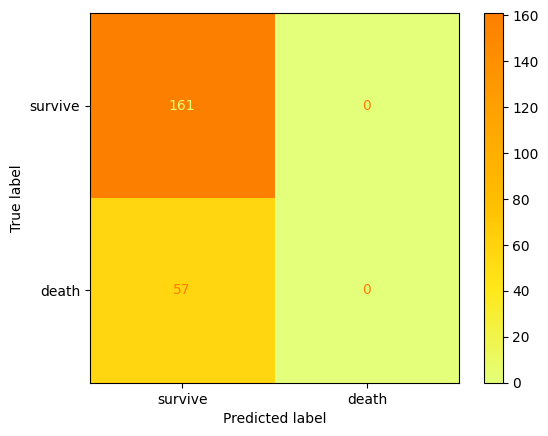

In [ ]:
level0 = list()
level0.append(('LogReg', logreg))
level0.append(('RF', RF))
level0.append(('XGB', XGB))
level0.append(('LGB', lgb_classifier))
level0.append(('KNN',KNN))
level0.append(('SVC', SVCClassifier))
level0.append(('GNB', GNB))
level0.append(('AdaBoost', ada_boost))
level0.append(('LDA', lda_classifier))
level0.append(('ElasticNet_LR', lr_elastic))
level0.append(('ExtraTrees', extra_trees))
level0.append(('QDA', qda_classifier))
level0.append(('GB', gb_classifier))
level1 = LogisticRegression(solver='liblinear')

stack = StackingClassifier(estimators=level0, final_estimator=level1, cv=5)
stack.fit(X_train, y_train)
metric(stack,'Stacking', X_test, y_test)

#### TabPFN

In [ ]:
# def setup_model_and_optimizer(config: dict) -> tuple[TabPFNClassifier, Optimizer, dict]:
#     """Initializes the TabPFN classifier, optimizer, and training configs."""
#     classifier_config = {
#         "ignore_pretraining_limits": True,
#         "device": config["device"],
#         "n_estimators": 2,
#         "random_state": config["random_seed"],
#         "inference_precision": torch.float32,
#     }
#     classifier = TabPFNClassifier(
#         **classifier_config, fit_mode="batched", differentiable_input=False
#     )
#     classifier._initialize_model_variables()

#     if len(classifier.models_) > 1:
#         raise ValueError(
#             f"Your TabPFNClassifier usese multiple models ({len(classifier.models_)}). "
#             "Finetuning is not supported for multiple models. Please use a single model."
#         )
#     model = classifier.models_[0]
#     # Optimizer uses finetuning-specific learning rate
#     optimizer = Adam(model.parameters(), lr=config["finetuning"]["learning_rate"])

#     print(f"Using device: {config['device']}")
#     print(f"Optimizer: Adam, Finetuning LR: {config['finetuning']['learning_rate']}")
#     print("----------------------------------\n")
#     return classifier, optimizer, classifier_config


# def evaluate_model(classifier: TabPFNClassifier,eval_config: dict,X_train: np.ndarray,y_train: np.ndarray,X_test: np.ndarray,y_test: np.ndarray,) -> tuple[float, float]:
#     """Evaluates the model's performance on the test set."""
#     eval_classifier = clone_model_for_evaluation(classifier, eval_config, TabPFNClassifier)
#     eval_classifier.fit(X_train, y_train)
#     try:
#         probabilities = eval_classifier.predict_proba(X_test)
#         y_test = np.ravel(y_test)
#         roc_auc = roc_auc_score(y_test, probabilities[:, 1])
#         log_loss_score = log_loss(y_test, probabilities)
#     except Exception as e:
#         print(f"An error occurred during evaluation: {e}")
#         roc_auc, log_loss_score = np.nan, np.nan

#     return roc_auc, log_loss_score

In [ ]:
# from tabpfn.model_loading import load_fitted_tabpfn_model, save_fitted_tabpfn_model
# from pathlib import Path
# config = {
#     # Sets the computation device ('cuda' for GPU if available, otherwise 'cpu').
#     "device": "cuda" if torch.cuda.is_available() else "cpu",
#     # The total number of samples to draw from the full dataset. This is useful for
#     # managing memory and computation time, especially with large datasets.
#     # For very large datasets the entire dataset is preprocessed and then
#     # fit in memory, potentially leading to OOM errors.
#     "num_samples_to_use": 100000,
#     # A seed for random number generators to ensure that data shuffling, splitting,
#     # and model initializations are reproducible.
#     "random_seed": 42,
#     # The proportion of the dataset to allocate to the valid set for final evaluation.
#     "valid_set_ratio": 0.2,
#     # During evaluation, this is the number of samples from the training set given to the
#     # model as context before it makes predictions on the test set.
#     "n_inference_context_samples": 10000,
# }
# config["finetuning"] = {
#     # The total number of passes through the entire fine-tuning dataset.
#     "epochs": 30,
#     # A small learning rate is crucial for fine-tuning to avoid catastrophic forgetting.
#     "learning_rate": 1e-5,
#     # Meta Batch size for finetuning, i.e. how many datasets per batch. Must be 1 currently.
#     "meta_batch_size": 1,
#     # The number of samples within each training data split. It's capped by
#     # n_inference_context_samples to align with the evaluation setup.
#     "batch_size": int(
#         min(
#             config["n_inference_context_samples"],
#             config["num_samples_to_use"] * (1 - config["valid_set_ratio"]),
#         )
#     ),
# }

# # --- Setup Data, Model, and Dataloader ---
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# classifier, optimizer, classifier_config = setup_model_and_optimizer(config)

# splitter = partial(train_test_split, test_size=config["valid_set_ratio"])
# training_datasets = classifier.get_preprocessed_datasets(
#     X_train, y_train, splitter, config["finetuning"]["batch_size"]
# )
# finetuning_dataloader = DataLoader(
#     training_datasets,
#     batch_size=config["finetuning"]["meta_batch_size"],
#     collate_fn=meta_dataset_collator,
# )
# loss_function = torch.nn.CrossEntropyLoss()

# eval_config = {
#     **classifier_config,
#     "inference_config": {
#         "SUBSAMPLE_SAMPLES": config["n_inference_context_samples"]
#     },
# }

# best_roc_auc=0
# # --- Finetuning and Evaluation Loop ---
# for epoch in range(config["finetuning"]["epochs"] + 1):
#     if epoch > 0:
#         # Finetuning Step
#         progress_bar = tqdm(finetuning_dataloader, desc=f"Finetuning Epoch {epoch}")
#         for (
#             X_train_batch,
#             X_test_batch,
#             y_train_batch,
#             y_test_batch,
#             cat_ixs,
#             confs,
#         ) in progress_bar:
#             if len(np.unique(y_train_batch)) != len(np.unique(y_test_batch)):
#                 continue  # Skip batch if splits don't have all classes

#             optimizer.zero_grad()
#             classifier.fit_from_preprocessed(
#                 X_train_batch, y_train_batch, cat_ixs, confs
#             )
#             predictions = classifier.forward(X_test_batch, return_logits=True)
#             loss = loss_function(predictions, y_test_batch.to(config["device"]))
#             loss.backward()
#             optimizer.step()

#             # Set the postfix of the progress bar to show the current loss
#             progress_bar.set_postfix(loss=f"{loss.item():.4f}")

#     # Evaluation Step (runs before finetuning and after each epoch)
#     eval_classifier = clone_model_for_evaluation(classifier, eval_config, TabPFNClassifier)
#     eval_classifier.fit(X_train, y_train)
#     probabilities = eval_classifier.predict_proba(X_test)
#     y_test = np.ravel(y_test)
#     epoch_roc_auc = roc_auc_score(y_test, probabilities[:, 1])
#     epoch_log_loss_score = log_loss(y_test, probabilities)
#     if epoch_roc_auc > best_roc_auc:
#         best_roc_auc = epoch_roc_auc
#         best_classifier= eval_classifier

#     status = "Initial" if epoch == 0 else f"Epoch {epoch}"
#     print(f" {status} Evaluation | Test ROC: {epoch_roc_auc:.4f}, Test Log Loss: {epoch_log_loss_score:.4f}\n")


In [ ]:
# save_fitted_tabpfn_model(best_classifier, Path("trained.tabpfn_fit"))
# mod = load_fitted_tabpfn_model(Path("trained.tabpfn_fit"), device="cpu")
# mod.fit(X_train, y_train)

In [ ]:
# Initialize a classifier
TABPFN_classifier = TabPFNClassifier()  # Uses TabPFN 2.5 weights, finetuned on real data.
TABPFN_classifier.fit(X_train, y_train)

TabPFNClassifier()

,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,TabPFN,0.781457,0.266667,0.166667,0.666667,0.675121,0.442061,"[[112, 3], [30, 6]]"
1,TabPFN,0.691176,0.000000,0.000000,0.000000,0.723404,0.606762,"[[47, 0], [21, 0]]"
2,TabPFN,0.691176,0.322581,0.238095,0.500000,0.708207,0.471388,"[[42, 5], [16, 5]]"


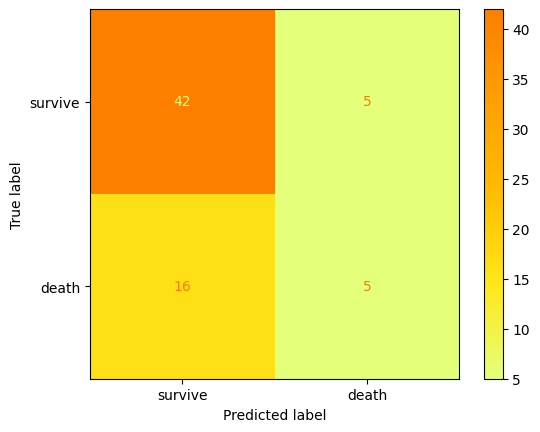

In [ ]:
metric(TABPFN_classifier,'TabPFN',X_test,y_test)

#### Result Analysis

In [ ]:
result

,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"
2,Bagging,0.711009,0.240964,0.175439,0.384615,0.674403,0.440643,"[[145, 16], [47, 10]]"
3,XGB,0.720183,0.383838,0.333333,0.452381,0.711997,0.422090,"[[138, 23], [38, 19]]"
4,LGB,0.729358,0.415842,0.368421,0.477273,0.682794,0.398681,"[[138, 23], [36, 21]]"
5,KNN,0.504587,0.460000,0.807018,0.321678,0.652228,0.351487,"[[64, 97], [11, 46]]"
6,SVC,0.756881,0.311688,0.210526,0.600000,0.769968,0.527107,"[[153, 8], [45, 12]]"
7,GNB,0.545872,0.377358,0.526316,0.294118,0.553667,0.316194,"[[89, 72], [27, 30]]"
8,AdaBoost,0.678899,0.406780,0.421053,0.393443,0.612292,0.381683,"[[124, 37], [33, 24]]"
9,LDA,0.665138,0.482270,0.596491,0.404762,0.690640,0.454104,"[[111, 50], [23, 34]]"


,Model,Accuracy,F1,Recall,Precision,ROC-AUC,AUC-PR,Confusion Matrix
0,LR,0.697248,0.535211,0.666667,0.447059,0.739893,0.512008,"[[114, 47], [19, 38]]"
1,RF,0.678899,0.186047,0.140351,0.275862,0.630108,0.357624,"[[140, 21], [49, 8]]"
2,Bagging,0.711009,0.240964,0.175439,0.384615,0.674403,0.440643,"[[145, 16], [47, 10]]"
3,XGB,0.720183,0.383838,0.333333,0.452381,0.711997,0.422090,"[[138, 23], [38, 19]]"
4,LGB,0.729358,0.415842,0.368421,0.477273,0.682794,0.398681,"[[138, 23], [36, 21]]"
5,KNN,0.504587,0.460000,0.807018,0.321678,0.652228,0.351487,"[[64, 97], [11, 46]]"
6,SVC,0.756881,0.311688,0.210526,0.600000,0.769968,0.527107,"[[153, 8], [45, 12]]"
7,GNB,0.545872,0.377358,0.526316,0.294118,0.553667,0.316194,"[[89, 72], [27, 30]]"
8,AdaBoost,0.678899,0.406780,0.421053,0.393443,0.612292,0.381683,"[[124, 37], [33, 24]]"
9,LDA,0.665138,0.482270,0.596491,0.404762,0.690640,0.454104,"[[111, 50], [23, 34]]"


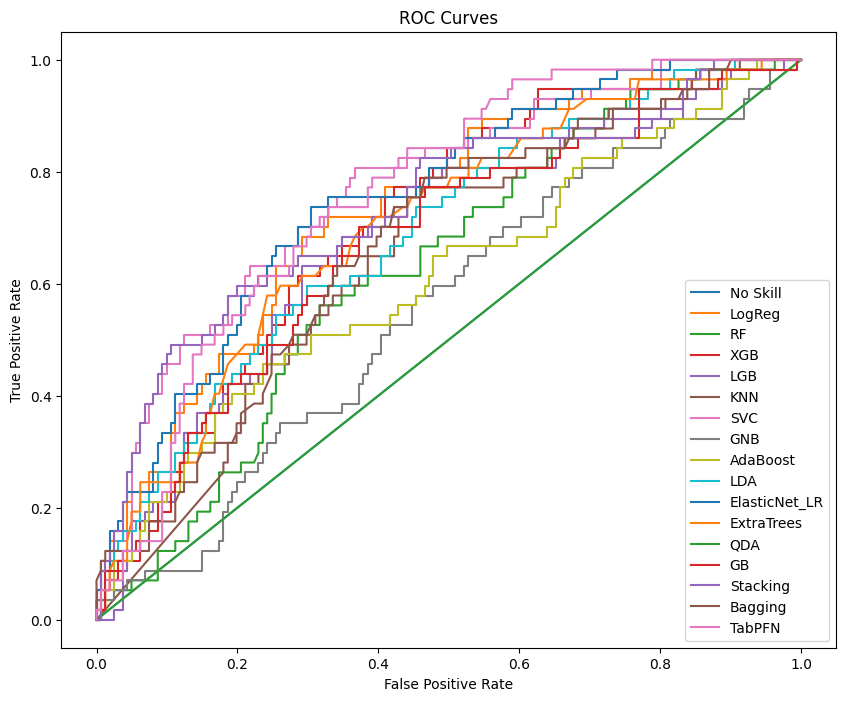

In [ ]:
def get_roc_auc_scores_and_curves(models, X_test, y_test):
    ns_probs = [0 for _ in range(len(y_test))]
    ns_auc = roc_auc_score(y_test, ns_probs)
    ns_fpr, ns_tpr, _ = roc_curve(y_test, ns_probs)
    roc_data = {'No Skill': (ns_fpr, ns_tpr)}

    for name, model in models:
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(X_test)[:, 1]
        else:
            if hasattr(model, 'decision_function'):
                decision_scores = model.decision_function(X_test)
                probs = (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min())
            else:
                raise AttributeError(f"{name} does not have predict_proba or decision_function")

        auc = roc_auc_score(y_test, probs)
        fpr, tpr, _ = roc_curve(y_test, probs)
        roc_data[name] = (fpr, tpr)

    return roc_data

models = level0 + [('Stacking', stack),('Bagging',bagging),('TabPFN',TABPFN_classifier)]
roc_data = get_roc_auc_scores_and_curves(models, X_test, y_test)
plt.figure(figsize=(10, 8))
for model_name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=model_name)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
result

In [ ]:
training=1
if training==1:
    with open("v2_with_meta_with_scale_with_smote_sepsis.json", "w") as f:
        json.dump(param, f, indent=4)

In [ ]:
import shap
import matplotlib.pyplot as plt

# model=logreg
# model=lr_elastic
# model=lda_classifier
model=SVCClassifier
X_sample=X_test
# model_name="Logistic Regression"
# model_name="Elastic Net Logistic Regression"
model_name="SVC"

# X_sample = pd.DataFrame(X_sample, columns=df.drop(['Mortality','Accession'], axis=1).columns)

# if "tree" in str(type(model)).lower() or "forest" in str(type(model)).lower():
#     explainer = shap.TreeExplainer(model)
#     shap_values = explainer(X_sample)
# elif "linear" in str(type(model)).lower() or "logistic" in str(type(model)).lower():
#     explainer = shap.LinearExplainer(model, X_sample)
#     shap_values = explainer(X_sample)
# else:
#     explainer = shap.Explainer(model.predict, X_sample, max_evals = 600)
#     shap_values = explainer(X_sample)

# shap.plots.beeswarm(shap_values, show=False,max_display=16)

# plt.xticks([-2, 0, 2, 4])
# plt.title(f"SHAP Feature Importance - {model_name}")
# plt.tight_layout()
# plt.show()

# if hasattr(shap_values, "values"):
#   shap_values = shap_values.values

# mean_abs_shap = np.abs(shap_values).mean(axis=0)
# importance_df = pd.DataFrame({'feature': X_sample.columns,'importance': mean_abs_shap}).sort_values(by='importance', ascending=False)
# top_features = importance_df['feature'].head(15).tolist()
# top_features


In [ ]:
import shap
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# model=logreg
# model=lr_elastic
model=SVCClassifier
X_sample=X_test
# model_name="Logistic Regression"
# model_name="Elastic Net Logistic Regression"
model_name="SVC"

# X_sample = pd.DataFrame(X_sample, columns=df.drop(['Mortality','Accession'], axis=1).columns)

# if "tree" in str(type(model)).lower() or "forest" in str(type(model)).lower():
#     explainer = shap.TreeExplainer(model)
#     shap_values = explainer(X_sample)
# elif "linear" in str(type(model)).lower() or "logistic" in str(type(model)).lower():
#     explainer = shap.LinearExplainer(model, X_sample)
#     shap_values = explainer(X_sample)
# else:
#     explainer = shap.Explainer(model.predict, X_sample, max_evals = 600)
#     shap_values = explainer(X_sample)

# group1 = ["PRC1","CAMP","DNAJB2","MAP1LC3A","GRINA","ATG9A"]
# group2 = ["Age","Male","Female"]
# group3 = [f for f in X_sample.columns if f not in group1 and group2]

# shap.plots.beeswarm(shap_values, show=False, max_display=16)
# ax = plt.gca()
# for label in ax.get_yticklabels():
#     feat = label.get_text()
#     if feat in group1:
#         label.set_color("purple")
#     elif feat in group2:
#         label.set_color("blue")
#     elif feat in group3:
#         label.set_color("orange")

# legend_elements = [
#     Patch(facecolor="purple", edgecolor="purple", label="Detrimental/Impaired"),
#     Patch(facecolor="orange", edgecolor="orange", label="Protective/Balanced"),
#     Patch(facecolor="blue", edgecolor="blue", label="Metadata")
# ]
# plt.legend(handles=legend_elements, loc="best",fontsize="x-small")
# plt.xticks([-2, 0, 2, 4])
# plt.title(f"SHAP Feature Importance - {model_name}")
# plt.tight_layout()
# plt.show()

In [ ]:
# from sklearn.inspection import permutation_importance
# result = permutation_importance(stack, X_test, y_test, n_repeats=20, random_state=42)
# X_columns=X.columns
# # X_columns=X_train.columns
# feature_importance = pd.Series(result.importances_mean, index=X_columns)
# print(feature_importance.nlargest(10))

In [ ]:
# metric(logreg, "LR", X_train, y_train)
# metric(RF, "RF", X_train, y_train)
# metric(XGB, "XGB", X_train, y_train)
# metric(lgb_classifier, "LGB", X_train, y_train)
# metric(KNN, "KNN", X_train, y_train)
# metric(SVCClassifier, "SVC", X_train, y_train)
# metric(GNB, "GNB", X_train, y_train)
# metric(ada_boost, "AdaBoost", X_train, y_train)
# metric(lda_classifier, "LDA", X_train, y_train)
# metric(lr_elastic, "ElasticNet_LR", X_train, y_train)
# metric(extra_trees, "ExtraTrees", X_train, y_train)
# metric(qda_classifier, "QDA", X_train, y_train)
# metric(gb_classifier, "GB", X_train, y_train)
# metric(stack,'Stacking', X_train, y_train)
# metric(voting_clf, 'VotingClassifier', X_train, y_train)

## Delong

https://medium.com/statistics-in-machine-learning/comparing-roc-curves-in-machine-learning-model-with-delongs-test-a-practical-guide-using-python-e70b5d20abde

In [ ]:
!pip install MLstatkit
from MLstatkit.stats import Delong_test

def model_proba(model):
    X=X_test
    if hasattr(model, 'predict_proba'):
        y_probs = model.predict_proba(X)[:, 1]
    elif hasattr(model, 'decision_function'):
        decision_scores = model.decision_function(X)
        y_probs = (decision_scores - decision_scores.min()) / (decision_scores.max() - decision_scores.min())
    else:
        raise ValueError(f"{model.__class__.__name__} has no predict_proba or decision_function")


    return y_probs

In [ ]:
import itertools
from statsmodels.stats.multitest import multipletests
def delong_ab_comparison(models: dict, X_test, y_test):
    """
    models: dict like {"logreg": logreg, "elastic": lr_elastic, ...}
    """
    results = []

    probs = {name: model_proba(model) for name, model in models.items()}
    for (name_a, prob_a), (name_b, prob_b) in itertools.combinations(probs.items(), 2):
        z_score, p_value = Delong_test(
            y_test, prob_a, prob_b,
            return_ci=False,
            return_auc=False,
            verbose=0
        )

        results.append({
            "model_A": name_a,
            "model_B": name_b,
            "z_score": z_score,
            "p_value": p_value
        })

    results_df = pd.DataFrame(results)

    pvals = results_df["p_value"]

    # Benjamini-Hochberg (FDR)
    results_df["Benjamini"] = multipletests(pvals, method="fdr_bh")[1]
    results_df["Simes"] = multipletests(pvals, method="simes-hochberg")[1]


    return results_df


In [ ]:
models = {
    "LR": logreg,
    "RF": RF,
    "XGB": XGB,
    "LGB": lgb_classifier,
    "KNN": KNN,
    "SVC": SVCClassifier,
    "GNB": GNB,
    "AdaBoost": ada_boost,
    "LDA": lda_classifier,
    "ElasticNet_LR": lr_elastic,
    "ExtraTrees": extra_trees,
    "QDA": qda_classifier,
    "GB": gb_classifier,
    "Stacking": stack,
    "Voting": voting_clf,
    "TabPFN": TABPFN_classifier
}


In [ ]:
df_results = delong_ab_comparison(models, X_test, y_test)

In [ ]:
df_results.to_excel("delong_results.xlsx", index=False)

In [ ]:
df_results

,model_A,model_B,z_score,p_value,Benjamini,Simes
0,LR,RF,-2.288234,0.022124,0.056487,0.936715
1,LR,XGB,-0.719774,0.471664,0.589580,0.936715
2,LR,LGB,-1.328492,0.184016,0.288863,0.936715
3,LR,KNN,-1.660999,0.096714,0.175843,0.936715
4,LR,SVC,0.886691,0.375245,0.489450,0.936715
...,...,...,...,...,...,...
115,GB,Voting,2.550082,0.010770,0.035899,0.915429
116,GB,TabPFN,2.415566,0.015711,0.046239,0.936715
117,Stacking,Voting,0.179103,0.857857,0.875164,0.936715
118,Stacking,TabPFN,0.651597,0.514661,0.619001,0.936715
